# <a id='toc1_'></a>[Value Based Segmentation for Amazing International Airlines Inc](#toc0_)
## <a id='toc1_1_'></a>[Data Mining Project](#toc0_)
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----
## <a id='toc1_2_'></a>[Summary](#toc0_)

Value-based segmentation, grouping customers according to their economic contribution.

**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc2_)    
- [Preprocessing](#toc3_)    
    - [Data Cleaning Steps](#toc3_1_1_)    
  - [Visualisation](#toc3_2_)    
    - [Extreme Outlier Reference (3×IQR)](#toc3_2_1_)    
  - [Outliers Detection](#toc3_3_)    
    - [Visualizations after working on outliers](#toc3_3_1_)    
  - [Scaling](#toc3_4_)    
- [Clustering](#toc4_)    
  - [Our Final data set for clusting](#toc4_1_)    
    - [Datasets Overview](#toc4_1_1_)    
  - [Ward Hierarchical](#toc4_2_)    
    - [Ward (k = 5)](#toc4_2_1_)    
    - [Ward (k = 7)](#toc4_2_2_)    
  - [K-Means](#toc4_3_)    
    - [K-mean (k = 6)](#toc4_3_1_)    
    - [K-mean (k = 8)](#toc4_3_2_)    
  - [Comparisons](#toc4_4_)    
    - [Final Conclusion: Value-Based Customer Segmentation](#toc4_4_1_)    
  - [Conclusions](#toc4_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<a class="anchor" id="0-bullet">    </a>
# <a id='toc2_'></a>[Imports](#toc0_)
[Back to Index](#toc)

In [81]:
# Standard library imports
import warnings
from math import ceil


# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

import umap

# Configuration
RANDOM_STATE = 42
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

sns.set_context("notebook")
sns.set_style("ticks")


In [82]:
MasterCustomerDB_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv')
MasterCustomerDB = MasterCustomerDB_Complete.copy()

In [83]:
cols_to_keep = [
    'Loyalty#',
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

Value_Based_Segmentation_clustering = MasterCustomerDB[cols_to_keep].copy()
Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.set_index('Loyalty#')

**Variables**

- *Customer Lifetime Value* – Total estimated monetary value generated by the customer over the duration of the relationship

- *Days_with_us* – Total number of days the customer has been active in the loyalty program since enrollment

- *Days_until_reengagement* – Number of days between cancellation and re-engagement for returning customers

- *Total_NumFlights* – Total number of flights taken by the customer during the observed period

- *Total_DistanceKM* – Total cumulative flight distance traveled by the customer in kilometers

- *Perc_Flights_With_Companions* – Percentage of flights taken with companions relative to the customer’s total flights

- *Dollar_Cost_Points_Remaining* – Estimated dollar value of loyalty points accumulated but not yet redeemed by the customer

- *Recency_Days* – Number of days since the customer’s most recent flight activity


# <a id='toc3_'></a>[Preprocessing](#toc0_)

Lets explore our EDA data set on NA and negativenumbers

In [84]:
Value_Based_Segmentation_clustering.isna().sum()


Customer Lifetime Value             0
Days_with_us                        0
Days_until_reengagement         16373
Total_NumFlights                 1471
Total_DistanceKM                 1471
Perc_Flights_With_Companions     1471
Dollar_Cost_Points_Remaining     1471
Recency_Days                     1471
dtype: int64

In [85]:
(Value_Based_Segmentation_clustering < 0).sum()

Customer Lifetime Value           0
Days_with_us                      0
Days_until_reengagement           0
Total_NumFlights                  0
Total_DistanceKM                  0
Perc_Flights_With_Companions      0
Dollar_Cost_Points_Remaining    481
Recency_Days                      0
dtype: int64

### <a id='toc3_1_1_'></a>[Data Cleaning Steps](#toc0_)

We proceed step by step with the data preparation:

1. **Days Until Re-engagement**  
   - `Days_until_reengagement` has **16,373 missing values**.  
   - These missing values correspond to customers who **did not leave the program**.  
   - We therefore impute these missing values with **0**.

2. **Value-Based Transaction Features**  
The following variables contain **1,471 missing values**:  
   - `Total_NumFlights`  
   - `Total_DistanceKM`  
   - `Dollar_Cost_Points_Remaining`  
   - `Recency_Days`  
These missing values indicate customers who **have not made any transactions**. Instead of imputing, we isolate these observations into a separate cluster labeled **“No Transaction”**.

3. **Negative Point Balances**  
There are **481 observations** with negative values in `Dollar_Cost_Points_Remaining`.  
Since it is not meaningful for a customer to redeem more points than they have earned,  
     we apply a **lower bound (floor) of 0** to this variable.


Identify “No Transaction” customers

In [86]:
transaction_cols = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]
no_transaction_mask = Value_Based_Segmentation_clustering[transaction_cols].isna().any(axis=1)
Value_Based_Segmentation_clustering_no_transaction = Value_Based_Segmentation_clustering[no_transaction_mask].copy()


Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.dropna(subset=transaction_cols)

print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


1471


Days_until_reengagement → impute with 0

In [87]:
Value_Based_Segmentation_clustering['Days_until_reengagement'] = (
    Value_Based_Segmentation_clustering['Days_until_reengagement']
    .fillna(0)
)

Negative Dollar_Cost_Points_Remaining → floor at 0

In [88]:
Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining'] = (
    Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining']
    .clip(lower=0)
)

Quick sanity checks

In [89]:
# Check remaining missing values
print(Value_Based_Segmentation_clustering.isna().sum())

# Check negative values
print((Value_Based_Segmentation_clustering < 0).sum())
# Check transaction group sizes
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
1471


## <a id='toc3_2_'></a>[Visualisation](#toc0_)

### <a id='toc3_2_1_'></a>[Extreme Outlier Reference (3×IQR)](#toc0_)

In addition to standard boxplots, we include a visual reference for *extreme outliers* using the **3× interquartile range (IQR)** rule.

While the conventional 1.5×IQR threshold highlights moderately unusual observations, the 3×IQR threshold identifies values that are *extremely distant* from the central distribution.

Importantly, these thresholds are **not used for automatic removal**.  
They are included solely as a diagnostic and interpretative tool to support exploratory data analysis and to assess whether certain variables contain values that may disproportionately influence visualization or downstream modeling.

Extreme outlier boundaries are displayed only when such values are present in the data.


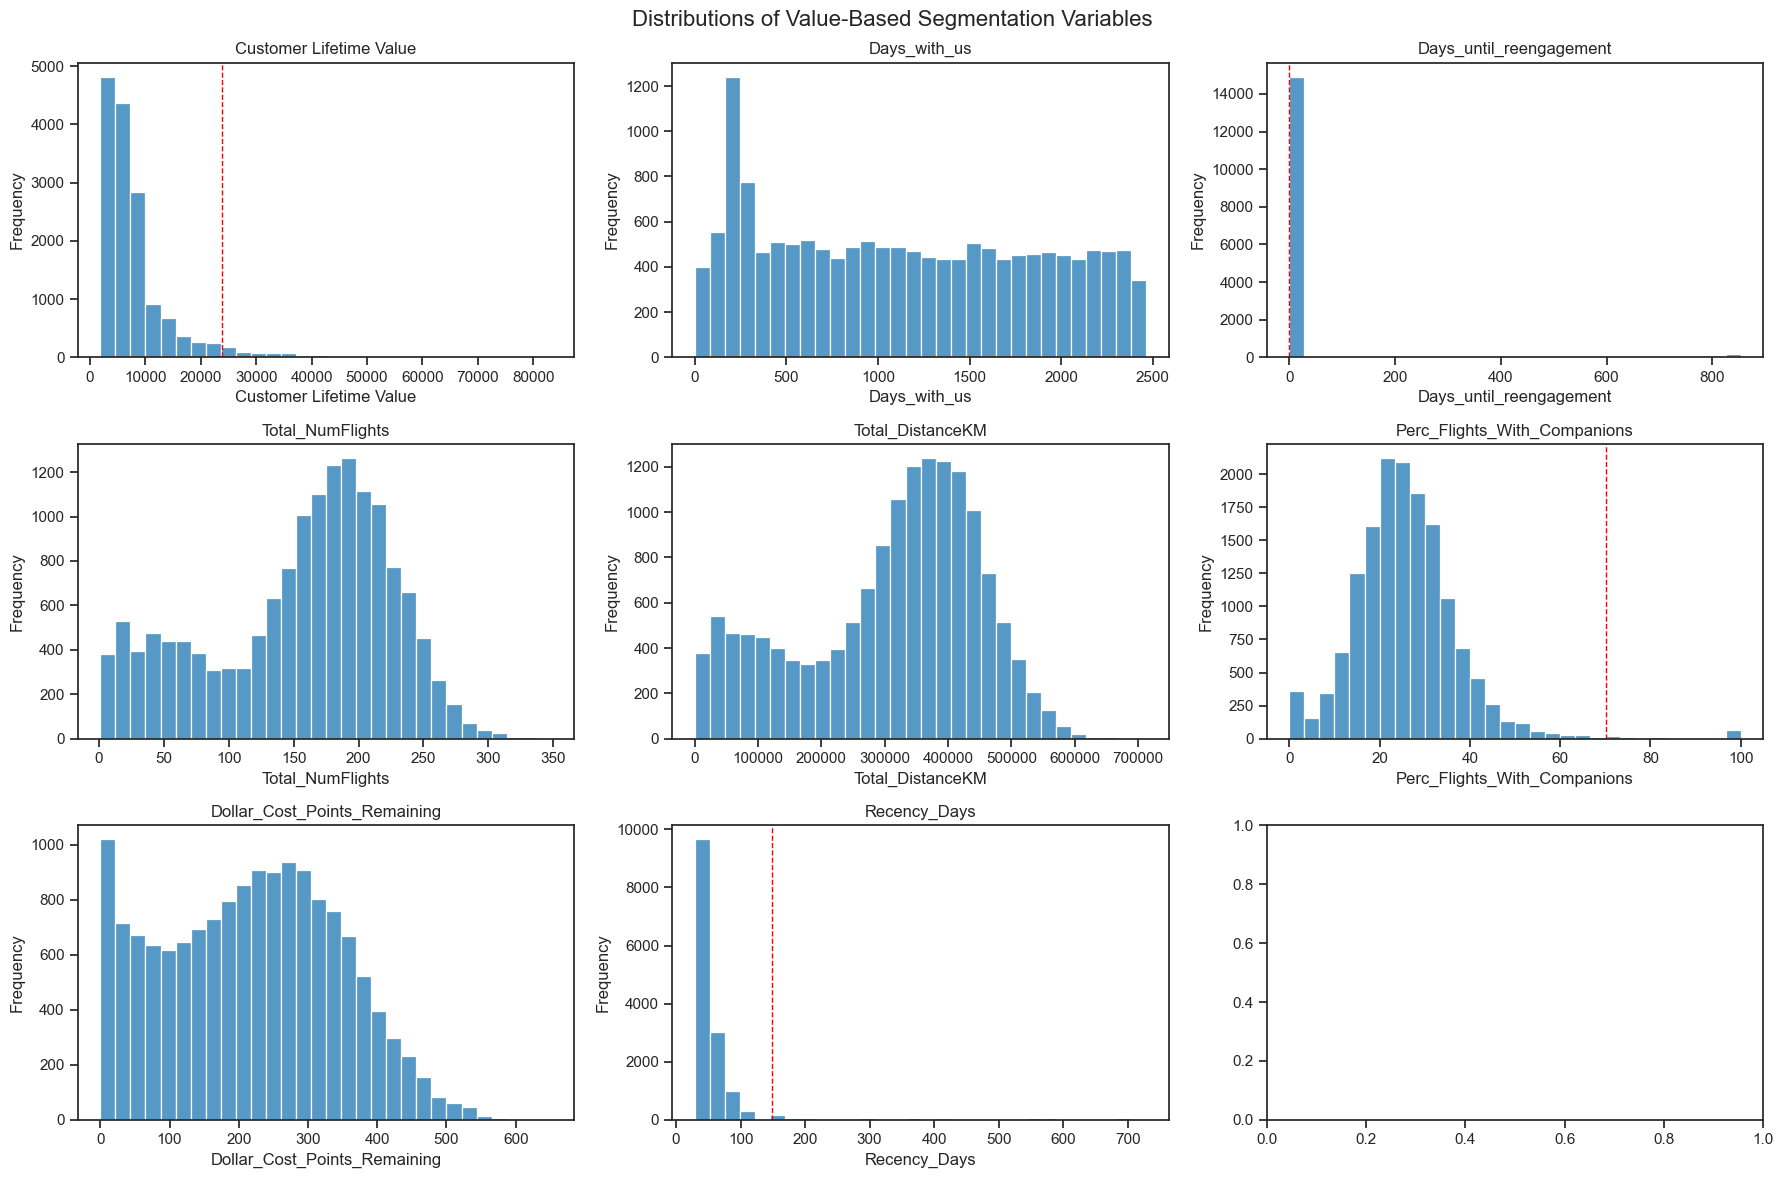

In [90]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    data = Value_Based_Segmentation_clustering[col].dropna()

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Value-Based Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()
# ...existing code...

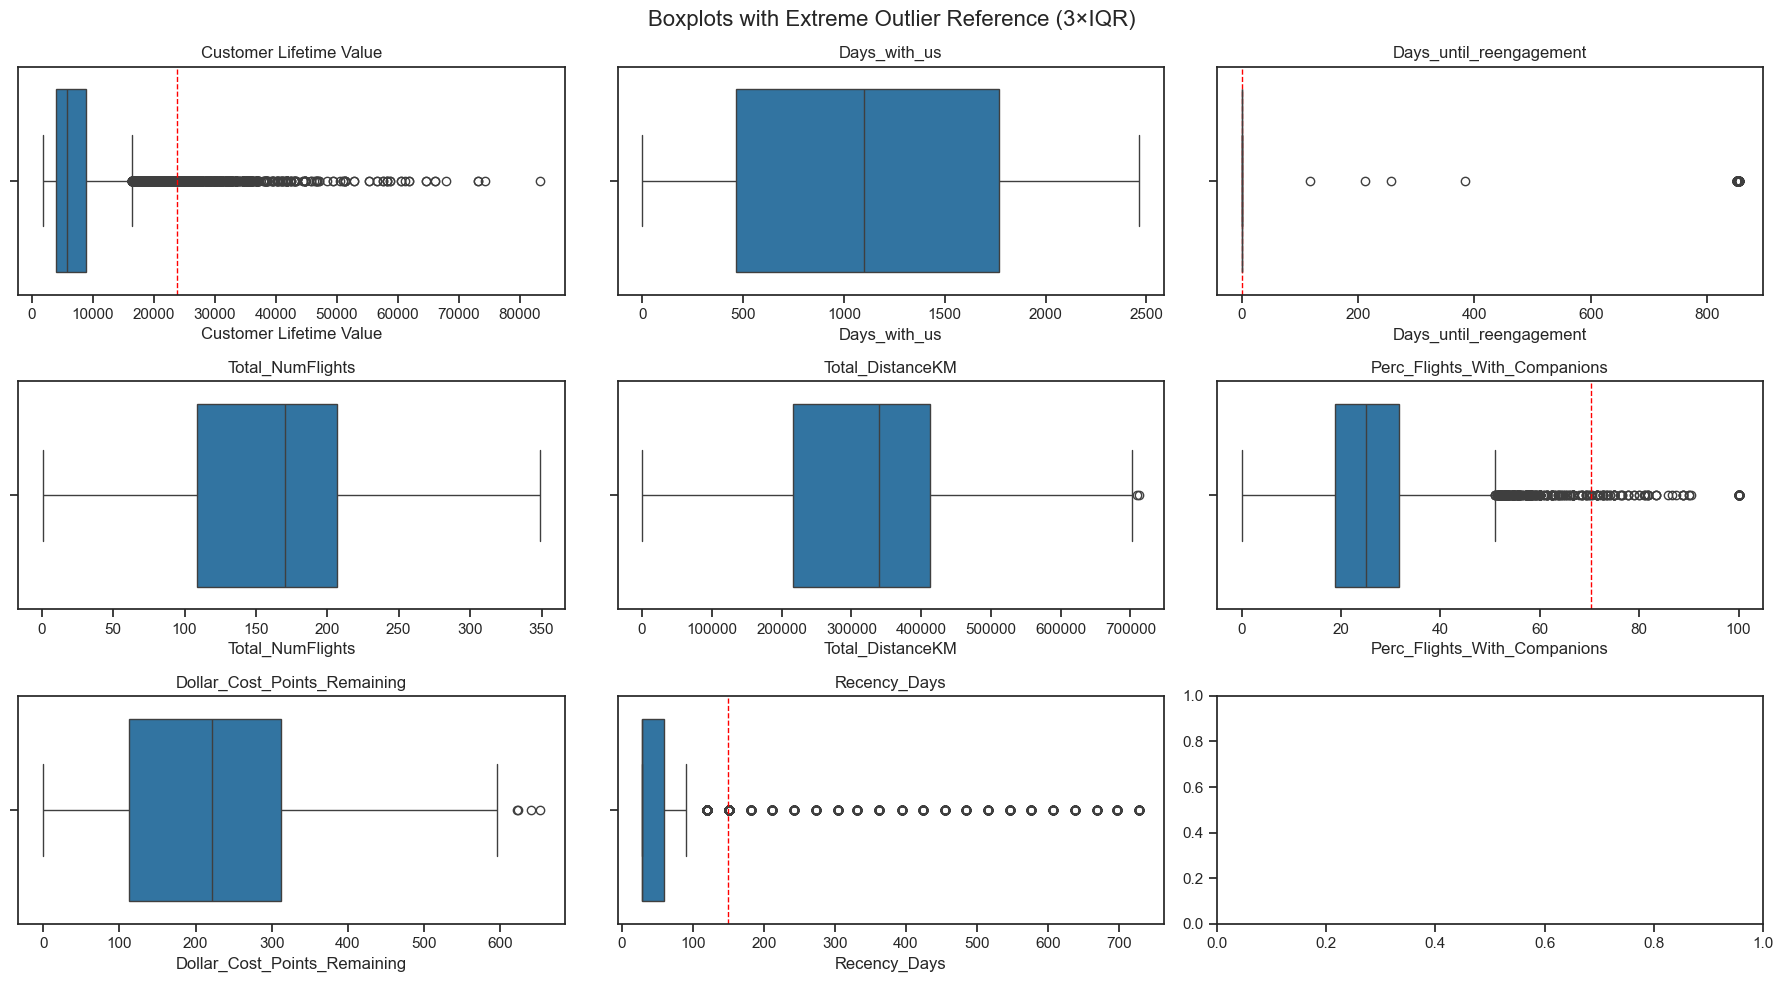

In [91]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()


Overall, the graphs look acceptable. There is some right skewness, but it does not appear to be a major issue at this stage.</br></br>
The main parameters that require closer inspection are Customer Lifetime Value, Days Until, Percentage of Flights with Companions, and Recency Days Reengagement. We analyze these features one by one to understand whether the extreme values represent true outliers or meaningful customer behavior. This assessment will help decide whether they should be preserved for clustering or handled during the scaling step.

## <a id='toc3_3_'></a>[Outliers Detection](#toc0_)

Customer Lifetime Value is a core variable in value-based segmentation. Extremely high values may indicate highly valuable customers rather than noise, so they should not be removed without careful consideration.
To better understand the distribution, we examine the percentage of customers with a lifetime value above our 'extreme outliers point' - 3*Inter qurtile range.

In [92]:
clv = Value_Based_Segmentation_clustering['Customer Lifetime Value']
Q1 = clv.quantile(0.25)
Q3 = clv.quantile(0.75)
IQR = Q3 - Q1

clv_upper_3iqr = Q3 + 3 * IQR

clv_perc_above_3iqr = (clv > clv_upper_3iqr).mean() * 100

clv_perc_above_3iqr


np.float64(3.8275610886696247)

The percentage of extreme values is 3% (a few), and since these customers remain high-value, we will apply a ceiling to limit values above three times the upper quartile. This helps reduce the impact of extremes and can potentially improve clustering results.

In [93]:
Value_Based_Segmentation_clustering['Customer Lifetime Value'] = (
    Value_Based_Segmentation_clustering['Customer Lifetime Value']
    .clip(upper=clv_upper_3iqr)
)

In [94]:
print(Value_Based_Segmentation_clustering['Customer Lifetime Value'].max() == clv_upper_3iqr)

True


Days until reengagement variable contains a large number of zeros, which correspond to customers who never left the program. In this case, standard outlier detection methods such as IQR are not informative.
To better understand the behavior of this feature, we analyze its distribution after excluding active users. This allows us to focus on customers who actually disengaged and observe how reengagement time is distributed.

In [95]:
dur = Value_Based_Segmentation_clustering['Days_until_reengagement']

# Percentage of zeros
perc_zero = (dur == 0).mean() * 100
print(perc_zero)

98.82127011456195


In [96]:
perc_800= (dur > 800).mean() * 100
print(perc_800)
print(perc_800 + perc_zero)

1.1522415734057347
99.97351168796769


A small fraction of customers (around 2%) shows extremely long re-engagement periods, in some cases exceeding 800 days. These customers typically flew with us, left the program, and rejoined after a long gap(for example due to promotion).
Although these values are extreme compared to the rest of the dataset, they reflect real customer behavior rather than noise.
Based on this, we during clusteing we will be carefull with this feature but wont change this feature and will not apply ceiling at this stage.

% flights with companions feature presents a situation similar to Customer Lifetime Value. While extreme values exist, they may reflect meaningful travel behavior rather than noise.
Before moving forward, it is important to examine how the data behaves at the extremes of this variable. Since this feature is essential for clustering, the decision on how to handle these values should be made carefully, balancing robustness with the need to preserve relevant customer patterns.

In [97]:
companions = Value_Based_Segmentation_clustering['Perc_Flights_With_Companions']
Q1 = companions.quantile(0.25)
Q3 = companions.quantile(0.75)
IQR = Q3 - Q1

companions_upper_3iqr = Q3 + 3 * IQR

companions_perc_above_3iqr = (companions > companions_upper_3iqr).mean() * 100

print(companions_perc_above_3iqr)
plt.show()

0.8343818290179458


About 1% of the records are above the extreme threshold. Although this is a small number, we can’t rescale the feature because it’s in percentages, and keeping the 0–100 scale is important. These customers still matter in the analysis, so we should keep them in mind during clustering.

(Recency) This situation is similar to what we observed with Customer Lifetime Value and Percentage of Flights With Companions. To proceed, it is important to examine how the data behaves at the extremes for this feature. Since it is essential for clustering, any decisions on handling extreme values should carefully balance preserving meaningful patterns with ensuring robust analysis.

In [98]:
recency = Value_Based_Segmentation_clustering['Recency_Days']
Q1 = recency.quantile(0.25)
Q3 = recency.quantile(0.75)
IQR = Q3 - Q1

recency_upper_3iqr = Q3 + 3 * IQR

recency_perc_above_3iqr = (recency > recency_upper_3iqr).mean() * 100

recency_perc_above_3iqr

np.float64(7.284285808886828)

There are quite a few observations, but if we consider typical travel behavior (most people don’t fly more than once a year for vacations) it makes to observe   flights occurring once a year two or more together

In [99]:
perc_above_365 = (recency > 365).mean() * 100
print(perc_above_365)


3.66863121647573


At this point we consider customers with long recency periods(>>3*Quartile) as extreme values in the dataset. To limit their impact on clustering while preserving overall patterns, we can apply a ceiling and set all recency values above 365 days to 365

In [100]:
Value_Based_Segmentation_clustering['Recency_Days'] = (
    Value_Based_Segmentation_clustering['Recency_Days']
    .clip(upper=365)
)

### <a id='toc3_3_1_'></a>[Visualizations after working on outliers](#toc0_)

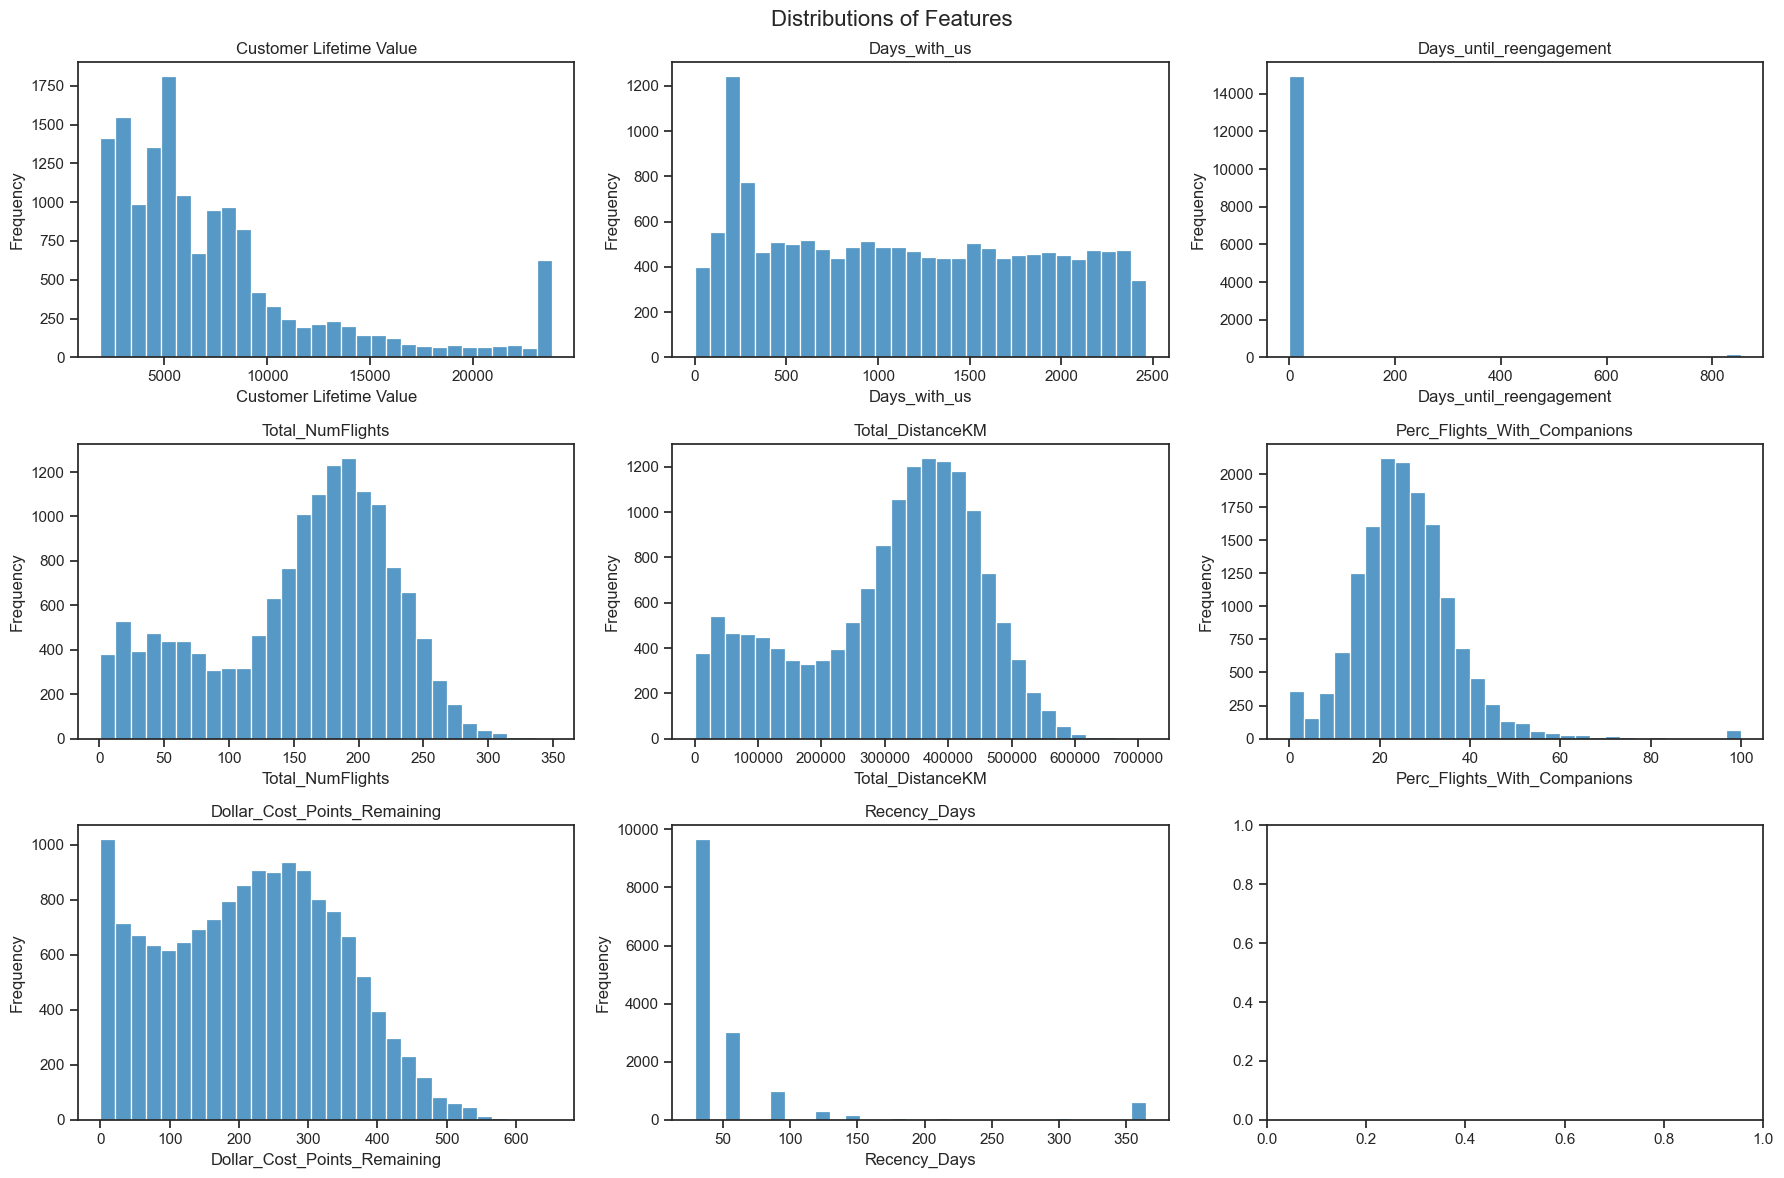

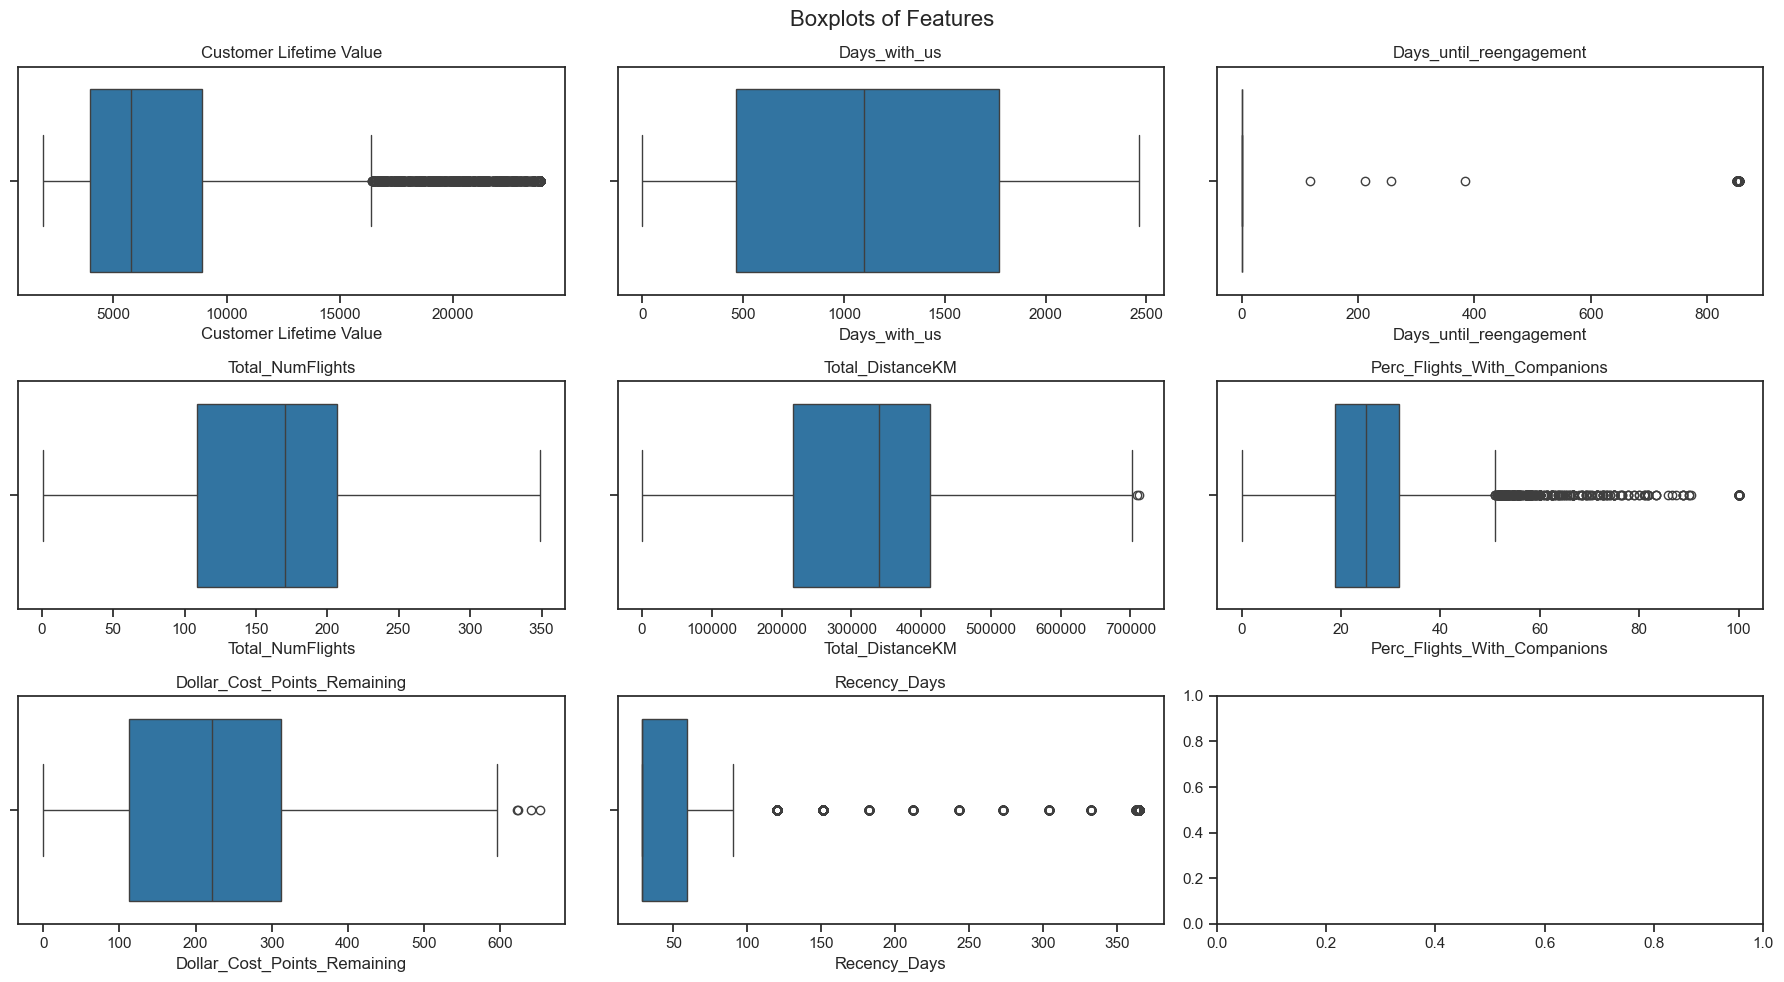

In [101]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.histplot(data, bins=30, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.boxplot(x=data, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()


## <a id='toc3_4_'></a>[Scaling](#toc0_)

We decided to apply Min-Max scaling from -1 to 1 for all features to scale our variables.

In [102]:

scaler = MinMaxScaler(feature_range=(-1, 1))

features_to_scale = [
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

# preserve original data
Value_Based_Segmentation_clustering_scaled = Value_Based_Segmentation_clustering.copy()

# apply Min-Max scaling to [-1, 1]
Value_Based_Segmentation_clustering_scaled[features_to_scale] = scaler.fit_transform(
    Value_Based_Segmentation_clustering[features_to_scale]
)

Value_Based_Segmentation_clustering_scaled.head()


,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Loyalty#,,,,,,,,
480934,-0.823155,-0.148884,-1.0,0.091954,0.395288,-0.413613,0.110600,-1.000000
549612,-0.823112,-0.166734,-1.0,0.597701,0.093611,-0.770609,-0.493173,-1.000000
429460,-0.823099,0.033671,-1.0,-0.316092,-0.355997,-0.333333,-0.463387,0.988095
608370,-0.823099,0.738742,-1.0,0.120690,0.082634,-0.408163,-0.317210,-1.000000
530508,-0.822822,0.238945,-1.0,-0.022989,0.028112,-0.263158,0.124095,-1.000000


In [103]:
Value_Based_Segmentation_clustering_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,15101.0,-0.479813,0.488835,-1.0,-0.811834,-0.647183,-0.358876,1.0
Days_with_us,15101.0,-0.074112,0.586347,-1.0,-0.621907,-0.108316,0.436917,1.0
Days_until_reengagement,15101.0,-0.976844,0.213307,-1.0,-1.000000,-1.000000,-1.000000,1.0
Total_NumFlights,15101.0,-0.113630,0.406062,-1.0,-0.379310,-0.028736,0.183908,1.0
Total_DistanceKM,15101.0,-0.133762,0.395944,-1.0,-0.392354,-0.047029,0.157877,1.0
Perc_Flights_With_Companions,15101.0,-0.482632,0.238956,-1.0,-0.623188,-0.500000,-0.366120,1.0
Dollar_Cost_Points_Remaining,15101.0,-0.335751,0.391398,-1.0,-0.656215,-0.319680,-0.042712,1.0
Recency_Days,15101.0,-0.811347,0.439942,-1.0,-1.000000,-1.000000,-0.821429,1.0


# <a id='toc4_'></a>[Clustering](#toc0_)

## <a id='toc4_1_'></a>[Our Final data set for clusting](#toc0_)

In [104]:
# Our Final data set for clustering

# Assume transaction_cols and no_transaction_mask were defined earlier, and
# Value_Based_Segmentation_clustering already had dropna(subset=transaction_cols)

# Ensure Final_Cluster exists
if 'Final_Cluster' not in Value_Based_Segmentation_clustering:
    Value_Based_Segmentation_clustering['Final_Cluster'] = 'Unspecified'

# Label parked no-transaction rows
Value_Based_Segmentation_clustering_no_transaction['Final_Cluster'] = 'No_transactions'
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])
# Reattach parked rows to the cleaned table
Value_Based_Segmentation_clustering = pd.concat(
    [Value_Based_Segmentation_clustering, Value_Based_Segmentation_clustering_no_transaction],
    axis=0
).sort_index()

# Build modelling set only from truly unclassified customers
unclassified_data = Value_Based_Segmentation_clustering[Value_Based_Segmentation_clustering.Final_Cluster == 'Unspecified']
data_for_modelling = Value_Based_Segmentation_clustering_scaled.loc[unclassified_data.index]

print('Final dataset shape:', Value_Based_Segmentation_clustering.shape)
print('No_transactions count:', (Value_Based_Segmentation_clustering.Final_Cluster == 'No_transactions').sum())
print('Unclassified (for modelling):', unclassified_data.shape)


1471
Final dataset shape: (16572, 9)
No_transactions count: 1471
Unclassified (for modelling): (15101, 9)


### <a id='toc4_1_1_'></a>[Datasets Overview](#toc0_)

Different versions of the data are used to clearly separate **model fitting**, **interpretation**, and **final analysis**.

`Value_Based_Segmentation_clustering_no_transaction`
Data of the customers who do not have any transactions.

---

`unclassified_data`
Customers whose `Final_Cluster` is `"Unspecified"`.  
This is the dataset used to explore and evaluate clustering solutions.

---

`data_for_modelling`
**Scaled numeric data** used to fit clustering algorithms.  
Scaling is applied only for modeling, not for interpretation.

---


## <a id='toc4_2_'></a>[Ward Hierarchical](#toc0_)
Ward’s method is used to explore the underlying structure. Using Euclidean distance with Ward linkage, we identify plausible ranges for the number of clusters before fixing the final choice.


In [28]:
# Helper functions for within-cluster dispersion and variance explained
def compute_ssw(X, labels):
    'Sum of squared distances within clusters.'
    X_np = X.values
    ssw = 0.0
    for lbl in np.unique(labels):
        cluster_points = X_np[labels == lbl]
        centroid = cluster_points.mean(axis=0)
        ssw += ((cluster_points - centroid) ** 2).sum()
    return ssw


def compute_r2(X, labels):
    'Proportion of variance explained by cluster assignment.'
    X_np = X.values
    sst = ((X_np - X_np.mean(axis=0)) ** 2).sum()
    ssw = compute_ssw(X, labels)
    return 1 - ssw / sst


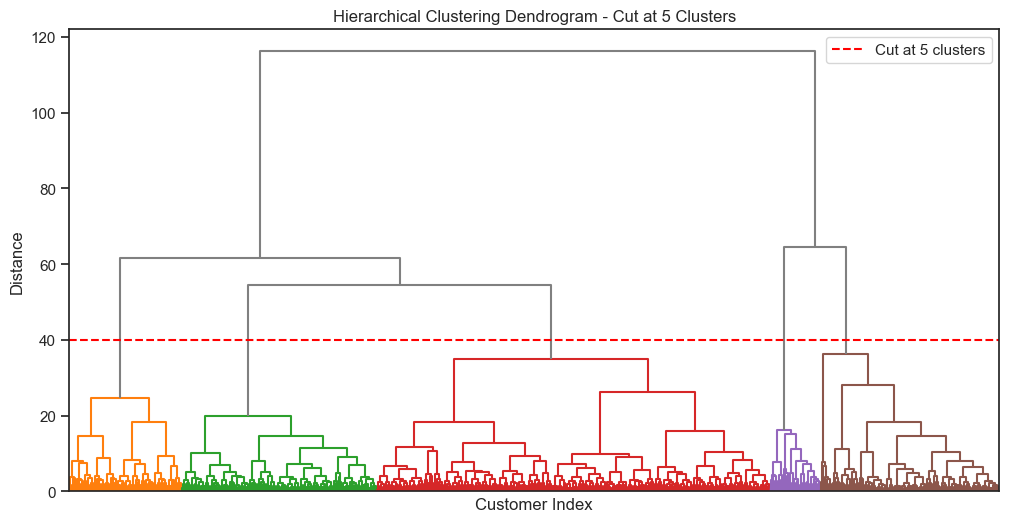

In [39]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(data_for_modelling, method='ward')

# Plot dendrogram with cut at 5 and 7 clusters
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=40, above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram - Cut at 5 Clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=40, color='r', linestyle='--', label='Cut at 5 clusters')
plt.legend()
plt.show()

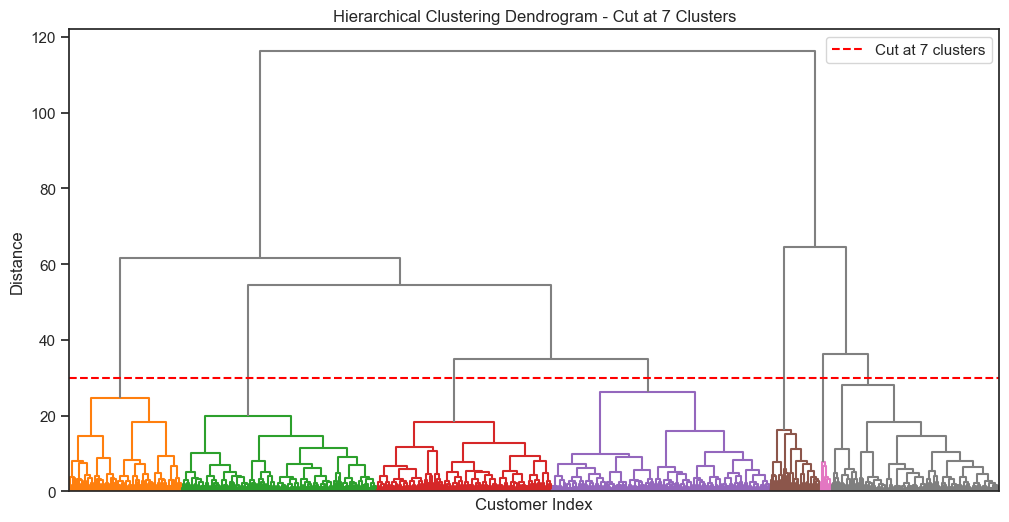

In [40]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(data_for_modelling, method='ward')

# Plot dendrogram with cut at 5 and 7 clusters
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=30, above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram - Cut at 7 Clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=30, color='r', linestyle='--', label='Cut at 7 clusters')
plt.legend()
plt.show()

**Dendrogram conclusion:** Using a visual cut at y ≈ 15 and 11 on the Ward tree, we carry forward candidate k values **5** and **7** for Ward evaluation.

In [43]:
ks = [5,7]  # Ward cluster counts to evaluate

ward_metrics = []
X = data_for_modelling.values
sst = ((X - X.mean(axis=0)) ** 2).sum()

for k in ks:
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ward.fit_predict(data_for_modelling)
    counts = pd.Series(labels).value_counts().sort_index()

    ssw = compute_ssw(data_for_modelling, labels)
    ssb = sst - ssw
    r2 = 1 - ssw / sst
    sil = silhouette_score(data_for_modelling, labels)

    ward_metrics.append({
        'model': f'Ward_{k}',
        'num_clusters': k,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'r2 (Higher is better, 0 to 1)': r2,
        'silhouette_score (Higher is better, −1 to +1)': sil,
        'min_cluster_size': counts.min(),
        'max_cluster_size': counts.max()
    })

df_cluster_metrics_ward = pd.DataFrame(ward_metrics)
display(df_cluster_metrics_ward)

,model,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)",min_cluster_size,max_cluster_size
0,Ward_5,5,8217.467498,12224.342627,0.598007,0.235498,818,6387
1,Ward_7,7,6944.064774,13497.745351,0.660301,0.213959,174,3546


### <a id='toc4_2_1_'></a>[Ward (k = 5)](#toc0_)

In [51]:
# Ward solution with 5 cluster
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=5)
hc_labels = hclust.fit_predict(data_for_modelling)
hc_labels

array([1, 1, 1, ..., 3, 0, 4])

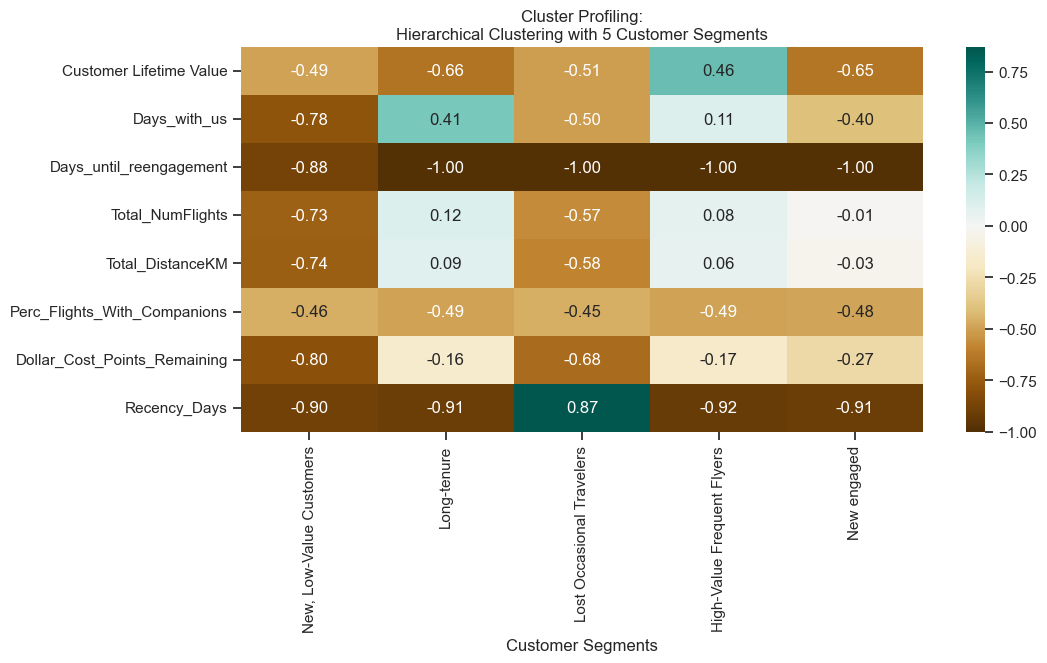

In [52]:
cluster_name_map_5 = {
    0: "New, Low-Value Customers",
    1: "Long-tenure",
    2: "Lost Occasional Travelers",
    3: "High-Value Frequent Flyers",
    4: "New engaged"
}
df_concat_hc_5 = pd.concat(
    (data_for_modelling, pd.Series(hc_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

hc_profile_5 = df_concat_hc_5.groupby('labels').mean().T

# Rename cluster columns with descriptive names
hc_profile_5 = hc_profile_5.rename(columns=cluster_name_map_5)

sns.heatmap(
    hc_profile_5,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Customer Segments")
plt.show()
df_concat_hc_5['cluster_name'] = df_concat_hc_5['labels'].map(cluster_name_map_5)


**Cluster Interpretations for Hierarchical Clustering with 6 Clusters:**

- **New, Low-Value Customers** – Customers with very low engagement, that reengaged.

- **Long-tenure** – Long-tenure, active customers with good engagement, but low CLV.

- **Lost Occasional Travelers** – Customers that do not buy something in a long time.

- **High-Value Frequent Flyers** – Customers that travel a lot and generate the best revenue.

- **New engaged** – New customers who are engaged.

In [53]:
df_concat_hc_5['cluster_name'].value_counts()

cluster_name
Long-tenure                   6387
New engaged                   3172
New, Low-Value Customers      2892
High-Value Frequent Flyers    1832
Lost Occasional Travelers      818
Name: count, dtype: int64

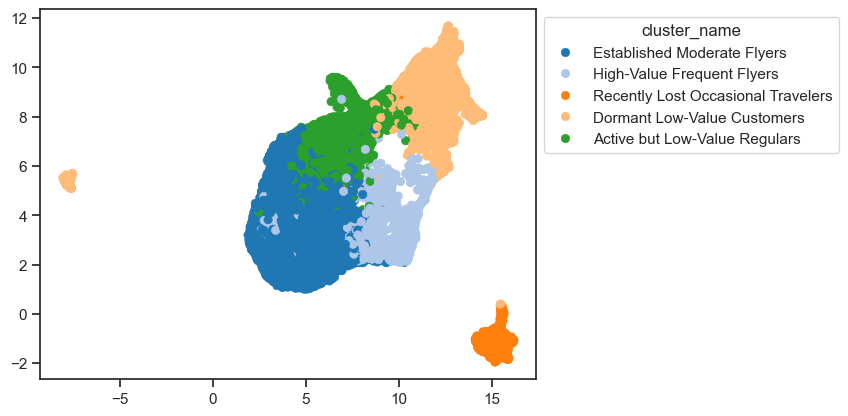

In [47]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_hc_5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### <a id='toc4_2_2_'></a>[Ward (k = 7)](#toc0_)

In [54]:
# Ward solution with 7 cluster
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=7)
hc_labels = hclust.fit_predict(data_for_modelling)
hc_labels

array([1, 1, 1, ..., 3, 0, 4])

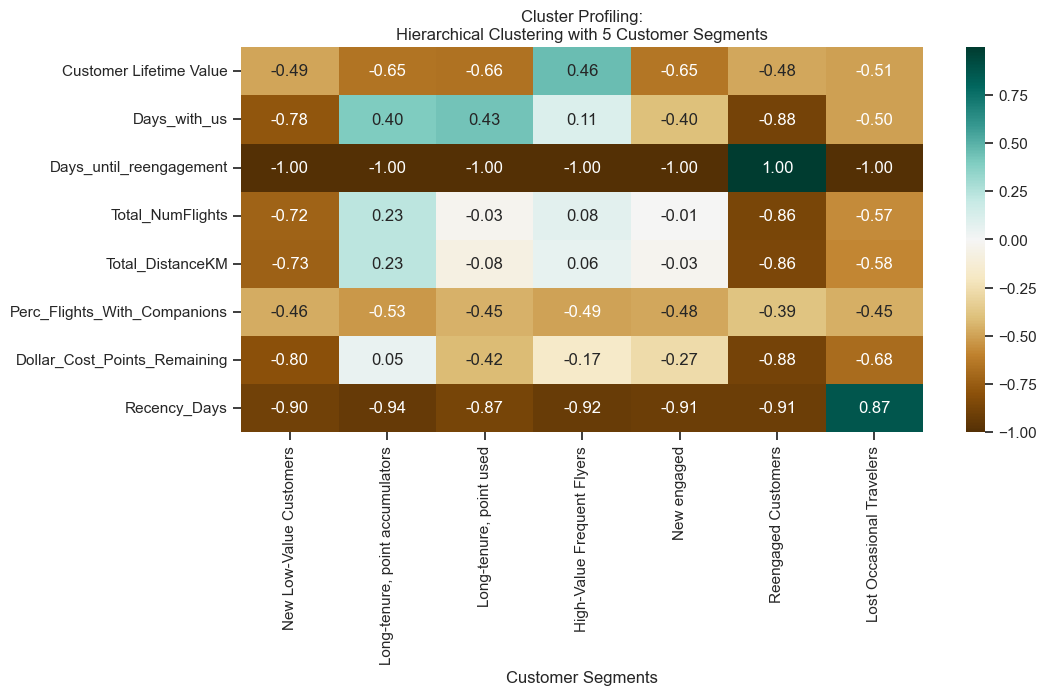

In [55]:
cluster_name_map_hc_7 = {
    0: "New Low-Value Customers",
    1: "Long-tenure, point accumulators",
    2: "Long-tenure, point used",
    3: "High-Value Frequent Flyers",
    4: "New engaged",
    5: "Reengaged Customers",
    6: "Lost Occasional Travelers"
}
df_concat_hc_7 = pd.concat(
    (data_for_modelling, pd.Series(hc_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

hc_profile_7 = df_concat_hc_7.groupby('labels').mean().T

# Rename cluster columns with descriptive names
hc_profile_7 = hc_profile_7.rename(columns=cluster_name_map_hc_7)

sns.heatmap(
    hc_profile_7,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Customer Segments")
plt.show()

df_concat_hc_7['cluster_name'] = df_concat_hc_7['labels'].map(cluster_name_map_hc_7)

- **New Low-Value Customers** – Customers with very low engagement, that are new.

- **Long-tenure, point accumulators** – Longer-tenured customers that acumulate the points.

- **Long-tenure, point used** – Longer-tenured customers that used the points.

- **High-Value Frequent Flyers** – Customers that travel a lot and generate the best revenue.

- **New engaged** – New customers who are engaged.

- **Reengaged Customers** Customers that reengaged.

- **Lost Occasional Travelers** – Customers that do not buy something in a long time.

In [56]:
df_concat_hc_7['cluster_name'].value_counts()

cluster_name
Long-tenure, point accumulators    3546
New engaged                        3172
Long-tenure, point used            2841
New Low-Value Customers            2718
High-Value Frequent Flyers         1832
Lost Occasional Travelers           818
Reengaged Customers                 174
Name: count, dtype: int64

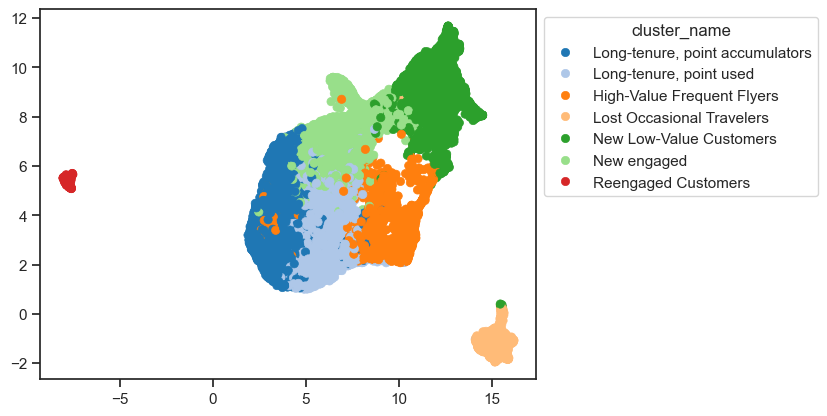

In [57]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_hc_7['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## <a id='toc4_3_'></a>[K-Means](#toc0_)
Apply K-Means with extensive initialization, evaluate the results quantitatively, and then select the final model by balancing inertia, R², silhouette scores, and cluster size distribution.

In [58]:
X = data_for_modelling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 11):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(data_for_modelling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)

In [59]:
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,13278.963583,7162.849631,0.371533,0.350402
1,3,11432.778908,9009.049377,0.225013,0.440717
2,4,9687.692123,10754.120097,0.246920,0.526085
3,5,9120.805925,11321.045180,0.188525,0.553818
4,6,7099.304829,13342.544617,0.236103,0.652709
5,7,6654.947737,13786.873481,0.211302,0.674445
6,8,5957.548430,14484.312825,0.253790,0.708563
7,9,5525.746449,14916.077092,0.234027,0.729685
8,10,5319.091709,15122.725894,0.229096,0.739794


Based on the results from the clustering metrics table, we are going to choose 6 and 8 clusters to create the segments. 

For 6 clusters:
- Silhouette Score: ~0.23
- R²: ~0.65 (explains 65% of variance)
- Provides a balanced number of segments for interpretation.

For 8 clusters:
- Silhouette Score: ~0.25
- R²: ~0.72 
- Offers more granularity for detailed customer segmentation.

We selected both (6 and 8) to compare their profiling.

### <a id='toc4_3_1_'></a>[K-mean (k = 6)](#toc0_)

In [60]:
# K mean solution with 6 cluster
number_clusters = 6
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(data_for_modelling)
km_labels

array([3, 2, 3, ..., 4, 5, 0], dtype=int32)

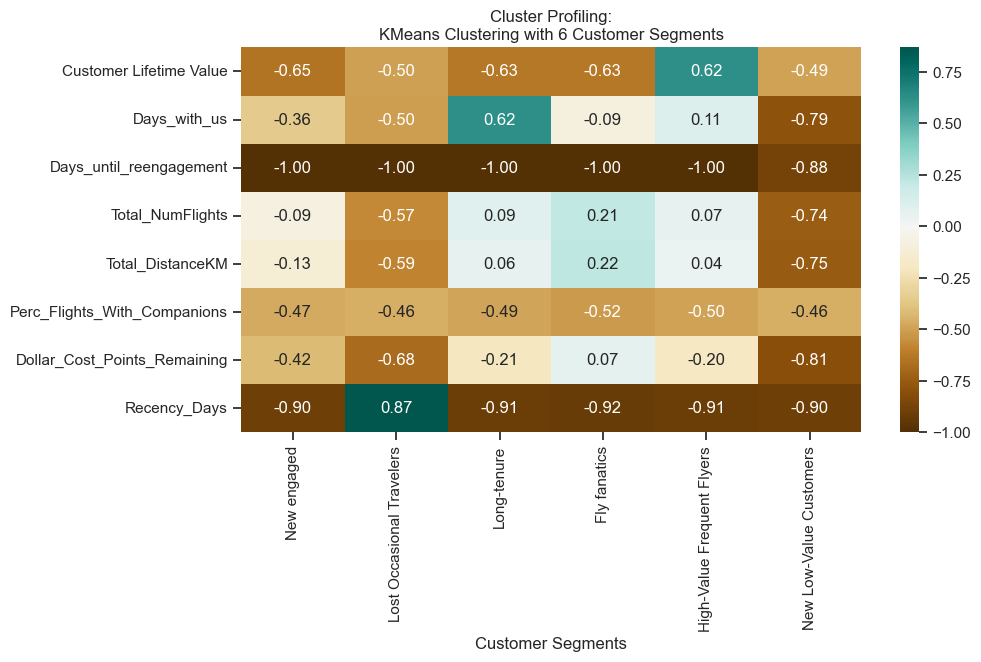

In [67]:
cluster_name_map_5 = {
    0: "New engaged",
    1: "Lost Occasional Travelers",
    2: "Long-tenure",
    3: "Fly fanatics",
    4: "High-Value Frequent Flyers",
    5: 'New Low-Value Customers'
}


df_concat_km5 = pd.concat(
    (data_for_modelling, pd.Series(km_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))

# Compute cluster profiles
km_profile = df_concat_km5.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map_5)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 6 Customer Segments")
plt.show()

df_concat_km5['cluster_name'] = df_concat_km5['labels'].map(cluster_name_map_5)

**Cluster Interpretations for KMeans with 5 Clusters:**

- **New engaged** – New customers who are engaged.

- **Lost Occasional Travelers** – Customers that do not buy something in a long time.

- **Long-tenure** – Longer-tenured customers that are engaged.

- **Fly fanatics** - Customers that travel the most and most distance.

- **High-Value Frequent Flyers** – Customers that travel a lot and generate the best revenue.

- **New Low-Value Customers** – Customers with very low engagement, that are new.


In [68]:
df_concat_km5['cluster_name'].value_counts()

cluster_name
Long-tenure                   4295
New engaged                   2970
New Low-Value Customers       2798
Fly fanatics                  2763
High-Value Frequent Flyers    1452
Lost Occasional Travelers      823
Name: count, dtype: int64

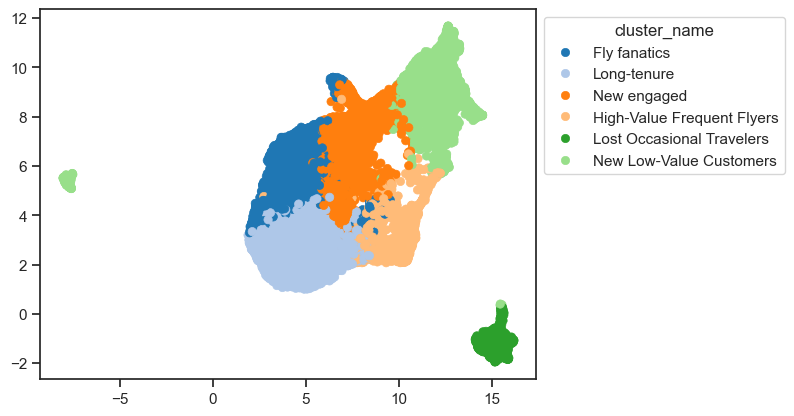

In [69]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_km5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### <a id='toc4_3_2_'></a>[K-mean (k = 8)](#toc0_)

In [105]:
# K mean solution with 8 cluster
number_clusters = 8
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(data_for_modelling)
km_labels

array([5, 2, 5, ..., 4, 1, 0], dtype=int32)

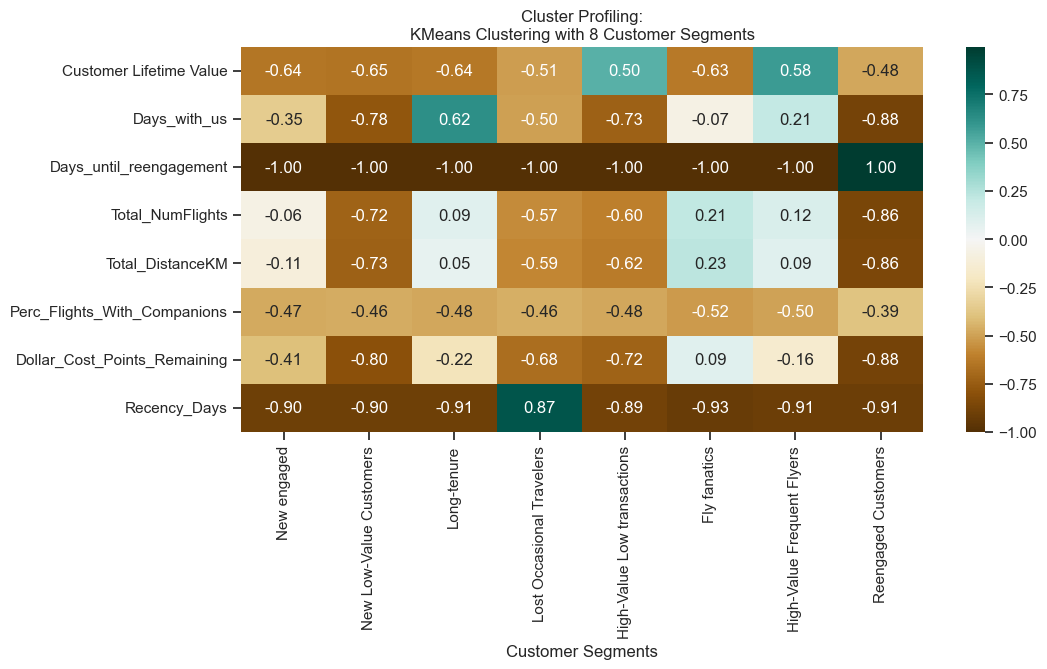

In [106]:
cluster_name_map_8 = {
    0: "New engaged",
    1: "New Low-Value Customers",
    2: "Long-tenure",
    3: "Lost Occasional Travelers",
    4: "High-Value Low transactions",
    5: "Fly fanatics",
    6: "High-Value Frequent Flyers",
    7: "Reengaged Customers"
}

df_concat_km8 = pd.concat(
    (data_for_modelling, pd.Series(km_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

km_profile = df_concat_km8.groupby('labels').mean().T

# Rename cluster columns
km_profile = km_profile.rename(columns=cluster_name_map_8)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 8 Customer Segments")
plt.show()

df_concat_km8['cluster_name'] = df_concat_km8['labels'].map(cluster_name_map_8)

**Cluster Interpretations for KMeans with 8 Clusters:**

- **New engaged** – New customers who are engaged.

- **New Low-Value Customers** – Customers with very low engagement, that are new.

- **Long-tenure** – Loyal customers that are engaged.

- **Lost Occasional Travelers** – Customers that do not buy something in a long time.

- **High-Value Low transactions** – Customers that travel rarely but generate the best revenue.

- **Fly fanatics** - Customers that travel the most and most distance.

- **High-Value Frequent Flyers** – Customers that travel a lot and generate the best revenue.

- **Reengaged Customers** Customers that reengaged.


In [107]:
df_concat_km8['cluster_name'].value_counts()

cluster_name
Long-tenure                    4162
New engaged                    3006
Fly fanatics                   2706
New Low-Value Customers        2312
High-Value Frequent Flyers     1365
Lost Occasional Travelers       817
High-Value Low transactions     559
Reengaged Customers             174
Name: count, dtype: int64

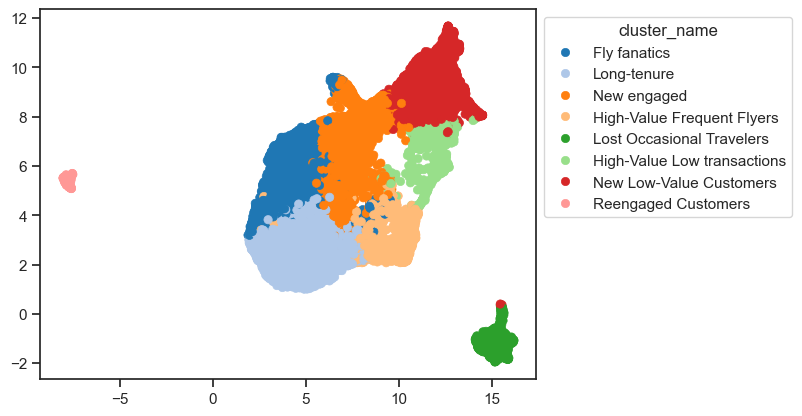

In [108]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_km8['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## <a id='toc4_4_'></a>[Comparisons](#toc0_)

In this section, we compare four approaches: K-Means with 5 clusters, K-Means with 8 clusters, Ward’s method with 5 clusters, and Ward’s method with 7 clusters. The evaluation emphasizes explained variance (R²), silhouette scores, and the balance of cluster sizes to assess both the quality of the segmentation and its interpretability.


In [109]:
# Compare metrics between KMeans and Hierarchical Clustering
df_kmeans_selection = df_cluster_metrics.iloc[[4, 6]].copy()
df_kmeans_selection['Method'] = 'KMeans'
ward_selection = df_cluster_metrics_ward.copy()
ward_selection['Method'] = 'Hierarchical'
df_final_comparison = pd.concat([df_kmeans_selection, ward_selection], ignore_index=True)

column_order = [
    'Method', 
    'num_clusters', 
    'r2 (Higher is better, 0 to 1)', 
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

df_final_comparison = df_final_comparison[column_order]
display(df_final_comparison)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,KMeans,6,0.652709,0.236103,7099.304829,13342.544617
1,KMeans,8,0.708563,0.253790,5957.548430,14484.312825
2,Hierarchical,5,0.598007,0.235498,8217.467498,12224.342627
3,Hierarchical,7,0.660301,0.213959,6944.064774,13497.745351


### <a id='toc4_4_1_'></a>[Final Conclusion: Value-Based Customer Segmentation](#toc0_)

The objective of this analysis was to identify the most appropriate clustering approach for **value-based customer segmentation**, where customer value is driven by behavioral, monetary, and lifecycle indicators (e.g., frequency, recency, distance traveled, loyalty value, tenure, and churn signals).

**Method Comparison Summary**

Four candidate solutions were evaluated:
- **KMeans** with 6 and 8 clusters  
- **Hierarchical (Ward)** with 5 and 7 clusters  

Evaluation was based on:
- Internal validation metrics (R², Silhouette, SSW, SSB)
- Cluster interpretability and economic meaning
- Stability and alignment of value-based segments across methods

**Key Findings**

- **K-means K=8** achieves the best results across all metrics of model comparizon.

**Conclusion**

**KMeans with 8 clusters is the preferred solution for value-based customer segmentation.**

It offers the best balance between statistical performance, interpretability, and business usability, enabling targeted strategies across the full customer value spectrum. Hierarchical clustering remains useful as a validation tool but is less suitable as a production segmentation framework.

## <a id='toc4_5_'></a>[Conclusions](#toc0_)

Several clustering models were assessed using quantitative performance metrics alongside interpretability considerations. Among them, the K-Means model with 8 clusters was selected as the final model, as it delivers the strongest overall performance.

This configuration offers the best balance between clustering quality and interpretability, making it the most appropriate choice for the analysis.

In [ ]:
# Rename the column in the original DataFrame
df_concat_km8 = df_concat_km8.rename(columns={'cluster_name': 'Value_Based_Cluster_Name'})
value_based_csv = df_concat_km8[['Value_Based_Cluster_Name']]

In [121]:
value_based_csv.info()
value_based_csv.head()

<class 'pandas.core.frame.DataFrame'>
Index: 15101 entries, 100018 to 999986
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Value_Based_Cluster_Name  15101 non-null  object
dtypes: object(1)
memory usage: 236.0+ KB


,Value_Based_Cluster_Name
Loyalty#,
100018,Fly fanatics
100102,Long-tenure
100140,Fly fanatics
100214,New engaged
100272,Long-tenure


We need to add our No Transaction group to the final cluster

In [122]:
value_based_csv = pd.concat([value_based_csv, Value_Based_Segmentation_clustering_no_transaction[['Final_Cluster']].rename(columns={'Final_Cluster': 'Value_Based_Cluster_Name'})], axis=0)
value_based_csv.head()

,Value_Based_Cluster_Name
Loyalty#,
100018,Fly fanatics
100102,Long-tenure
100140,Fly fanatics
100214,New engaged
100272,Long-tenure


In [124]:
value_based_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 100018 to 652627
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Value_Based_Cluster_Name  16572 non-null  object
dtypes: object(1)
memory usage: 258.9+ KB


In [133]:
value_based_csv.to_csv("value_based_clusters.csv", index=True)
print("CSV file created: value_based_clusters.csv")

CSV file created: value_based_clusters.csv


In [125]:
value_based_csv.head()

,Value_Based_Cluster_Name
Loyalty#,
100018,Fly fanatics
100102,Long-tenure
100140,Fly fanatics
100214,New engaged
100272,Long-tenure
